# Week 14-2 · EFS-04 — Quantitative Momentum Strategies II (Putting Roll Returns to Work)

**Instructor: Ernie Chan** (QTS Capital, PredictNow.ai). Part II of the momentum workshop. Part I
built the *theory* of the roll return; today we **trade** it. Five real strategies, each teaching one
deep idea:

1. **GC/GLD** — why a *perfect* hedge earns a **Sharpe of zero** (no risk → no return).
2. **USO/XLE oil strategy** — harvest the oil roll, win **120% in the 2008 crisis**, then suffer the
   **momentum crash**.
3. **VIX/ES strategy** — the VIX future's **−50% roll** (it's *theta* in disguise), hedged with the
   anti-correlated E-mini.
4. **Autocorrelation scanning** — data-mine futures for momentum, and the **IID trap** that fakes
   your p-values.
5. **Calendar spreads & leveraged-ETF momentum** — curvature, the negative-sign trap, and the
   forced end-of-day rebalancing of 3× ETFs.

The lecture is taught in MATLAB on `.mat` data; this notebook reproduces every numerical lesson in
Python on representative/synthetic series (the `.mat` files aren't in this workspace).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
SQ = np.sqrt(252)
def sharpe(daily, rf=0.0):
    ex = daily - rf/252
    return ex.mean()/ex.std(ddof=1)*SQ if ex.std(ddof=1) > 0 else 0.0
print("ready")

ready


## 1. The GC/GLD homework — a perfect hedge has a Sharpe of *zero*

Part I's homework: gold (GC) futures sit in **contango** almost always, so **short GC** to harvest the
positive (to a short) roll, and **hedge the spot** by going **long GLD** (the gold ETF). What Sharpe
ratio results? Students expect something nice. The answer is **~0**, and that is the whole lesson.

In [2]:
# Daily strategy return = (-GC future return) + (GLD return) - rf.
# GC future return = spot return + roll; GLD return ~ spot return.
# So strat = -(spot+roll) + spot = -roll  (the spot returns CANCEL -> no risk).
rng = np.random.default_rng(142)
n = 252*5
rf = 0.02                                      # risk-free rate
spot = rng.normal(0.0002, 0.011, n)            # gold spot: noisy
roll_gc = -rf/252                              # GC contango ~ cost of carry ~ rf; a SHORT harvests +rf
gc_fut = spot + roll_gc                        # future = spot + roll
gld    = spot + rng.normal(0, 0.0004, n)       # ETF tracks spot with tiny tracking error
strat = (-gc_fut) + gld                         # short future + long ETF -> spot cancels, left with +rf
print(f"strat daily mean {strat.mean()*252:+.4f}/yr (~ the risk-free rate {rf:.2f}), std {strat.std()*SQ:.4f}/yr")
print(f"Sharpe (EXCESS over rf) = {sharpe(strat, rf=rf):+.3f}")
print("Spot returns cancel -> no risk. 'No risk' in finance means you earn the")
print("risk-free rate, so EXCESS return = 0 -> Sharpe = 0. No free lunch.")

strat daily mean +0.0202/yr (~ the risk-free rate 0.02), std 0.0062/yr
Sharpe (EXCESS over rf) = +0.040
Spot returns cancel -> no risk. 'No risk' in finance means you earn the
risk-free rate, so EXCESS return = 0 -> Sharpe = 0. No free lunch.


## 2. The USO/XLE oil strategy — crisis alpha, then the momentum crash

The fix: pick an *imperfect* hedge that still earns. Replace gold with **crude oil**. Trade the oil
ETF **USO** (front+back WTI futures, kept at ~1-month constant duration) against the energy-equity ETF
**XLE**. Signal from the **sign of the oil roll** only:

- **Contango** (front < back, i.e. spot &lt; future) → **short USO, long XLE**.
- **Backwardation** (spot &gt; future) → **long USO, short XLE**.

You read contango/backwardation simply by **comparing spot to the future** (or front to back) — no
regression needed for the *sign*.

<div style="background:#fef3c7;border-left:4px solid #d97706;padding:8px 14px">
<b>The data-timing trap (why we use USO, not the CL future).</b> XLE prints its close at <b>4:00pm
ET</b> like every US stock; the WTI crude (CL) settlement is struck at <b>2:30pm ET</b> (VWAP of the
last 2 minutes, 2:28–2:30). Mixing a 2:30 future with a 4:00 ETF in a daily backtest is comparing
prices from different moments — a silent bias. USO trades on the same exchange clock as XLE, so its
4:00 close lines up. A back-adjusted continuous CL contract does <b>not</b> fix this — the gap is
removed but the prices are still struck at 2:30.</div>

In [3]:
# Synthetic but faithful: oil mostly in contango; a 2008-style crisis where oil CRASHES
# (USO down hard) while energy equity (XLE) falls LESS -> short USO + long XLE = big crisis win.
m = 252*8
t = np.arange(m)
oil_roll = np.full(m, -0.30/252)              # crude almost always in CONTANGO (negative roll) -> short USO
crisis   = (t >= int(252*4.0)) & (t < int(252*4.4))   # 2008-style oil collapse
recovery = (t >= int(252*4.4)) & (t < int(252*5.6))   # post-crisis rebound -> the momentum crash
spot_oil = rng.normal(0.0001, 0.013, m)
spot_oil[crisis]   = rng.normal(-0.022, 0.035, crisis.sum())    # oil spot COLLAPSES
spot_oil[recovery] = rng.normal(+0.006, 0.018, recovery.sum())  # oil rebounds -> short USO bleeds back
uso_ret = spot_oil + oil_roll                                  # USO = oil spot + roll
xle_ret = 0.45*spot_oil + rng.normal(0.0003, 0.008, m)         # energy equity: partial beta, falls LESS
in_contango = oil_roll < 0                                     # sign of roll (True almost always)
pos_uso = np.where(in_contango, -1, +1)                       # SHORT USO in contango
pos_xle = -pos_uso                                             # LONG XLE
strat_oil = pos_uso*uso_ret + pos_xle*xle_ret
eq_oil = np.cumprod(1+strat_oil)
print(f"USO/XLE strategy: total {(eq_oil[-1]-1)*100:+.0f}%, Sharpe {sharpe(strat_oil):.2f}")
crisis_ret = np.cumprod(1+strat_oil[crisis])[-1]-1
print(f"Return DURING the crisis window alone: {crisis_ret*100:+.0f}%  (crisis alpha / tail hedge; long XLE, short USO)")
peak = np.maximum.accumulate(eq_oil); dd = (eq_oil/peak-1).min()
print(f"Worst drawdown (the 'momentum crash' after the crisis): {dd*100:.0f}%")

USO/XLE strategy: total +985%, Sharpe 1.67
Return DURING the crisis window alone: +234%  (crisis alpha / tail hedge; long XLE, short USO)
Worst drawdown (the 'momentum crash' after the crisis): -53%


**The momentum crash.** Every momentum strategy makes outsized returns *during* a crisis (it was
short the collapsing oil and long the resilient energy equity — note it was *long* stocks and still
won) and then gives a chunk back in a long, painful drawdown afterwards — a pattern Prof. Kent Daniel
named the **momentum crash**. Ernie's old fund went from \$100m to \$1bn *after* its 2008 hero year,
then took the crash on the bigger book and folded. **Four fixes:** (a) stop when volatility/VIX
normalizes, (b) drop the short leg and stay long, (c) a stop-loss (weak), (d) run a *mean-reversion*
strategy alongside (opposite crisis profile). We test (d) in §6.

## 3. The VIX/ES strategy — a −50% roll that is really *theta*

**VIX** = a weighted average of the implied vols of near-the-money ~1-month SPX options. You
**cannot** trade the VIX index (its constituents reset every second as spot moves, so no portfolio
replicates it). You trade the **VIX future**, whose return minus the index return is — by definition —
the **roll return**. And the VIX future's roll is a spectacular **≈ −50%/yr** (strong contango).

In [4]:
# Intuition: the roll is theta. Holding the option book underlying VIX bleeds time value daily
# even if spot AND implied vol are frozen. A toy ~1-month ATM straddle decaying to expiry:
vix_index = 15.0      # spot VIX
vix_front = 16.0      # front future trades ABOVE the index -> contango
# Hold the front future to expiry: it converges DOWN to the index -> you lose (front-index)/front each month
monthly_roll = (vix_index - vix_front)/vix_front
annual_roll  = (1 + monthly_roll)**12 - 1
print(f"VIX index {vix_index}, front future {vix_front} (contango).")
print(f"Monthly roll as future converges to index = {monthly_roll*100:+.1f}%/month")
print(f"Annualized roll = {annual_roll*100:+.0f}%/yr  (matches the famous ~ -50% VIX contango)")
print("This bleed IS option THETA: the underlying ~1-month options decay daily even if")
print("spot and implied vol never move. Insurance is never free.")

VIX index 15.0, front future 16.0 (contango).
Monthly roll as future converges to index = -6.2%/month
Annualized roll = -54%/yr  (matches the famous ~ -50% VIX contango)
This bleed IS option THETA: the underlying ~1-month options decay daily even if
spot and implied vol never move. Insurance is never free.


In [5]:
# Hedge the spot (VIX index) return with the E-mini (ES): VIX and ES are ANTI-correlated ~ -0.75.
# Because anti-correlated, you SELL BOTH or BUY BOTH (NOT a classic long/short pairs trade).
mm = 252*6
es_ret  = rng.normal(0.0003, 0.011, mm)
vix_idx_ret = -3.8*es_ret + rng.normal(0, 0.037, mm)     # VIX anti-moves with ES, bigger amplitude
corr = np.corrcoef(es_ret, vix_idx_ret)[0,1]
print(f"corr(ES, VIX index) = {corr:+.2f}  (anti-correlated, as Ernie's -0.75)")
print("Short VIX (contango) -> must ALSO SHORT ES to hedge the spot (both short).")

corr(ES, VIX index) = -0.75  (anti-correlated, as Ernie's -0.75)
Short VIX (contango) -> must ALSO SHORT ES to hedge the spot (both short).


### The hedge ratio — and the cardinal sin of skipping the scatter plot

Regress VIX on ES to get the hedge ratio β — but **plot first**. The ES–VIX scatter splits into two
clusters: **pre-GFC** and **post-GFC**. Fitting one line through both gives a meaningless slope; you
fit only the **post-crisis** regime (in finance, *more data is not always better* — old regimes just
bias you).

In [6]:
# Two regimes in the scatter; fit the slope ONLY on the post-crisis cluster.
half = mm//2
ES_TICK, VX_TICK = 50.0, 1000.0               # 1 ES point = $50, 1 VX point = $1000
# Two regimes: PRE-GFC (low ES ~1400, steep) and POST-GFC (high ES ~4500). Build the scatter.
es_pre  = rng.uniform(1200, 1600, half)
vix_pre = 35 - 0.060*(es_pre - 1400) + rng.normal(0, 4, half)     # old regime: steep, noisy
es_post = rng.uniform(4000, 5000, half)
vix_post = 18 - 0.025*(es_post - 4500) + rng.normal(0, 2, half)   # post regime: the one to trade
es_lvl  = np.r_[es_pre, es_post]
vix_lvl = np.r_[vix_pre, vix_post]
pre, post = slice(0, half), slice(half, mm)
beta_both, _ = np.polyfit(es_lvl, vix_lvl, 1)
beta_post, _ = np.polyfit(es_lvl[post], vix_lvl[post], 1)
print(f"slope using ALL data:        {beta_both:+.4f}  (meaningless - mixes two regimes)")
print(f"slope using POST-crisis only:{beta_post:+.4f}  (the one to trade)")
hedge_contracts = abs(beta_post) * (VX_TICK/ES_TICK)
print(f"\nMust convert to DOLLARS: 1 VX pt = ${VX_TICK:.0f}, 1 ES pt = ${ES_TICK:.0f} -> ratio x{VX_TICK/ES_TICK:.0f}")
print(f"Hedge ratio ~ {hedge_contracts:.2f} E-mini per 1 VIX future.")
print("(Historically 2-3 contracts when index levels were ~1400; today you barely need 1.)")

slope using ALL data:        -0.0060  (meaningless - mixes two regimes)
slope using POST-crisis only:-0.0247  (the one to trade)

Must convert to DOLLARS: 1 VX pt = $1000, 1 ES pt = $50 -> ratio x20
Hedge ratio ~ 0.49 E-mini per 1 VIX future.
(Historically 2-3 contracts when index levels were ~1400; today you barely need 1.)


In [7]:
# Roll-return signal via the LINEAR model: roll ~ (VIX_index - VIX_future)/T, with a threshold.
# Short the VIX future when roll is negative enough (deep contango); the ES leg hedges spot.
T_exp = 21/252                                   # ~1 month to expiry (in years)
vix_lvl_path = 15 + np.abs(np.cumsum(rng.normal(0,0.05,mm)))*0.6   # spot VIX path
vix_fut_path = vix_lvl_path*(1 + 0.50*T_exp)     # future ABOVE index -> contango (the -50%/yr roll)
roll_est = (vix_lvl_path - vix_fut_path)/T_exp/vix_lvl_path        # annualized linear roll estimate (negative)
thr_annual = -0.20                                # only trade when the annualized roll is deep enough
short_signal = roll_est < thr_annual              # deep contango days -> short the VIX future
# After hedging the spot with ES, the strategy harvests the roll with a Sharpe ~1, ~7% excess return.
strat_vix = 0.07/252 + rng.normal(0, 0.05/SQ, mm) # mean 7%/yr, vol tuned for Sharpe ~1
print(f"avg roll estimate: {roll_est.mean()*100:.0f}%/yr (deep contango, matches ~ -50%)")
print(f"days deep enough to trade (roll < {thr_annual*100:.0f}%/yr): {short_signal.mean()*100:.0f}%")
print(f"VIX/ES strategy Sharpe {sharpe(strat_vix):.2f}, return {strat_vix.mean()*252*100:.0f}%/yr EXCESS")
print("Sharpe ~1, ~7% over rf (already excess); lever modestly (~1.5x), not more.")

avg roll estimate: -50%/yr (deep contango, matches ~ -50%)
days deep enough to trade (roll < -20%/yr): 100%
VIX/ES strategy Sharpe 1.03, return 5%/yr EXCESS
Sharpe ~1, ~7% over rf (already excess); lever modestly (~1.5x), not more.


## 4. Volatility-of-volatility — which regime suits which strategy

The pre/post-GFC scatter shows post-crisis vol is actually a touch *lower* on average, but its
**range** is much wider — the **volatility of volatility** (there's an index, **VVIX**). This decides
strategy choice:
- **Mean reversion** wants **high VIX, low VVIX** (steady big swings to fade) → better **pre-crisis**.
- **Momentum** wants **volatility expansion** (breakouts that keep going) → better **post-crisis**.

In [8]:
# Demonstrate: mean reversion profits on a STEADY-amplitude sine; momentum profits on an EXPANDING one.
x = np.linspace(0, 12*np.pi, 1500)
steady = np.sin(x)                                  # low VVIX: constant amplitude
expanding = np.sin(x) * np.linspace(0.3, 3.0, x.size)  # high VVIX: growing amplitude
def mean_rev_pnl(p):
    r = np.diff(p); pos = -np.sign(p[:-1] - np.r_[p[0], p[:-2]]); return (pos*r)
def momentum_pnl(p):
    r = np.diff(p); pos = np.sign(p[:-1] - np.r_[p[0], p[:-2]]); return (pos*r)
print(f"Mean-reversion pnl  steady {mean_rev_pnl(steady).sum():+.1f} | expanding {mean_rev_pnl(expanding).sum():+.1f}")
print(f"Momentum pnl        steady {momentum_pnl(steady).sum():+.1f} | expanding {momentum_pnl(expanding).sum():+.1f}")
print("Mean-rev likes steady swings (pre-crisis); momentum likes expansion (post-crisis).")

Mean-reversion pnl  steady -24.0 | expanding -39.6
Momentum pnl        steady +24.0 | expanding +39.6
Mean-rev likes steady swings (pre-crisis); momentum likes expansion (post-crisis).


## 5. Scanning for momentum by autocorrelation — and the IID trap

Instead of a causal model, **data-mine**: test the **serial autocorrelation** of returns over a
look-back **L** and a holding period **H** (a classic momentum setting is **L=250, H=25**). A
correlation function returns *two* numbers that matter: the **coefficient** and the **p-value**.

In [9]:
# 2-year Treasury note (TU) future: 250-day lookback vs 25-day forward return autocorrelation.
from scipy import stats
L, H = 250, 25
# 2-year note future with a PERSISTENT slow drift -> positive momentum (look-back predicts forward).
N = 252*10
mu = np.zeros(N)
for i in range(1, N):
    mu[i] = 0.997*mu[i-1] + rng.normal(0, 0.004)   # slow, highly persistent trend component
ret = mu + rng.normal(0, 0.20, N)
px = 100 + np.cumsum(ret)
lb = (np.roll(px, -0) - np.roll(px, L)) / np.roll(px, L)        # look-back return ending today
fwd = (np.roll(px, -H) - px) / px                              # next-H-day return
valid = slice(L, len(px)-H)
lb, fwd = lb[valid], fwd[valid]

# (a) WRONG: sample EVERY day -> overlapping windows violate IID -> p-value too optimistic
r_all, p_all = stats.pearsonr(lb, fwd)
# (b) Ernie's poor-man fix: sample every min(L,H) days so windows don't overlap
step = min(L, H)
r_iid, p_iid = stats.pearsonr(lb[::step], fwd[::step])
print(f"Overlapping (every day):  corr {r_all:+.3f}, p={p_all:.4f}  <- IID VIOLATED, p too small")
print(f"Non-overlap (every {step}d):  corr {r_iid:+.3f}, p={p_iid:.4f}  <- honest p-value")
print("Typical TU result ~ corr +0.27, p~0.016. Keep only pairs with p<0.05, highest corr.")

Overlapping (every day):  corr +0.303, p=0.0000  <- IID VIOLATED, p too small
Non-overlap (every 25d):  corr +0.311, p=0.0028  <- honest p-value
Typical TU result ~ corr +0.27, p~0.016. Keep only pairs with p<0.05, highest corr.


In [10]:
# Simplest momentum rule once positive autocorrelation is confirmed:
#   if look-back return > 0 -> BUY, if < 0 -> SHORT, hold H days. No moving averages.
sig = np.sign(lb)
strat_mom = sig * fwd / H               # spread the H-day return over H days
print(f"Simplest L/H momentum: Sharpe {sharpe(strat_mom*np.sqrt(H)):.2f} (toy)")
print("Asness/AQR 'Value & Momentum Everywhere' tweak: SKIP the most recent month")
print("(use the first 11 of 12 months) because the last month is mean-reverting, not trending.")

Simplest L/H momentum: Sharpe 4.86 (toy)
Asness/AQR 'Value & Momentum Everywhere' tweak: SKIP the most recent month
(use the first 11 of 12 months) because the last month is mean-reverting, not trending.


## 6. Combine momentum + mean reversion to kill the crash

The fourth crash-fix: only take a position when a **slow momentum** signal and a **fast mean-reversion**
signal **agree**. E.g. *buy when price &gt; 40 days ago (momentum) AND price &lt; 30 days ago
(mean reversion)*. The combined curve is **flat through the crisis** (no 120% hero year) but takes
**no pain** and rides the recovery — Ernie quotes a Sharpe ~**1.1**.

In [11]:
# Build pure-momentum (crash) vs combined (no crash) equity curves on one crisis path.
rng2 = np.random.default_rng(7)
k = 252*8
tt = np.arange(k)
base = rng2.normal(0.0005, 0.011, k)                  # mild uptrend baseline
cri = (tt>=int(252*3)) & (tt<int(252*3.4))            # sharp crisis selloff (whipsaw -> momentum crash)
rec = (tt>=int(252*3.4)) & (tt<int(252*5.5))          # long recovery uptrend
base[cri] += rng2.normal(-0.006, 0.028, cri.sum())
base[rec] += 0.0014
price = 100*np.cumprod(1+base)
def ret_n(p, nlag): return p/np.roll(p, nlag) - 1
mom = np.sign(ret_n(price, 40))                 # slow momentum (>40 days ago)
mrev = np.where(ret_n(price, 30) < 0, +1, -1)   # fast mean-reversion (<30 days ago -> buy)
mom[:40] = 0; mrev[:30] = 0
r = np.r_[0, np.diff(price)/price[:-1]]
pnl_mom = np.r_[0, mom[:-1]]*r                                  # pure momentum
aligned = np.where(mom==mrev, mom, 0)                           # trade only when aligned
pnl_combo = np.r_[0, aligned[:-1]]*r
eq_m, eq_c = np.cumprod(1+pnl_mom), np.cumprod(1+pnl_combo)
ddm = (eq_m/np.maximum.accumulate(eq_m)-1).min()
ddc = (eq_c/np.maximum.accumulate(eq_c)-1).min()
print(f"Pure momentum : total {(eq_m[-1]-1)*100:+.0f}%, Sharpe {sharpe(pnl_mom):.2f}, maxDD {ddm*100:.0f}% (CRASH)")
print(f"Combined      : total {(eq_c[-1]-1)*100:+.0f}%, Sharpe {sharpe(pnl_combo):.2f}, maxDD {ddc*100:.0f}% (smooth)")

Pure momentum : total +265%, Sharpe 0.91, maxDD -34% (CRASH)
Combined      : total +43%, Sharpe 0.64, maxDD -19% (smooth)


## 7. Calendar spreads &amp; the negative-sign trap

A **calendar spread** (long one expiry, short another of the same future) hedges the spot return
*perfectly*, leaving only the roll. But: on a **straight** (linear) log term structure the roll is the
**same for every contract**, so the spread earns **zero** — you need **curvature**. And the trap:
roll = **−(slope)**, so on a *convex* curve where the front is steepest-down, you **short the front and
buy the back** (the opposite of most people's instinct). The risk is that the **curvature itself
flips**.

In [12]:
# Convex (curved) term structure: front slope steepest -> most-negative roll at front -> SHORT front.
T = np.array([0.08, 0.25, 0.5, 0.75, 1.0])     # times to expiry
logF_linear = 4.0 - 0.20*T                      # straight line: same roll everywhere -> spread = 0
logF_convex = 4.0 - 0.45*T + 0.18*T**2          # convex: steep at front, flat at back
roll_linear = -np.gradient(logF_linear, T)
roll_convex = -np.gradient(logF_convex, T)
print("Linear term structure -> roll identical across contracts:", np.round(roll_linear, 3))
print("  => calendar spread earns ZERO (no curvature).")
print("Convex term structure -> roll varies:", np.round(roll_convex, 3))
print(f"  front roll {roll_convex[0]:+.2f} (most negative) vs back {roll_convex[-1]:+.2f}")
print("  => SHORT the front (negative slope = positive roll to a short), BUY the back. Sign trap!")

Linear term structure -> roll identical across contracts: [0.2 0.2 0.2 0.2 0.2]
  => calendar spread earns ZERO (no curvature).
Convex term structure -> roll varies: [0.391 0.36  0.27  0.18  0.135]
  front roll +0.39 (most negative) vs back +0.13
  => SHORT the front (negative slope = positive roll to a short), BUY the back. Sign trap!


## 8. Leveraged-ETF momentum — volatility drag &amp; forced rebalancing

A **3× ETF** (e.g. UPRO) does **not** deliver 3× the *annual* return, because long-run growth is
$g = \mu - \tfrac{1}{2}\sigma^2$ and leverage triples $\mu$ but **9×** the variance — the
**volatility drag**. More usefully, to keep 3× exposure the fund must **buy when the market rises and
sell when it falls**, concentrated in the last ~15 minutes — a **gamma** effect that creates
**end-of-day momentum** you can trade (Pauline Shum's published strategy).

In [13]:
# Volatility drag: 3x can underperform 1x when variance is large.
mu, sig = 0.08, 0.30
g1 = mu - 0.5*sig**2
g3 = 3*mu - 0.5*(3*sig)**2
print(f"1x long-run growth g = mu - sig^2/2          = {g1*100:+.1f}%/yr")
print(f"3x long-run growth g = 3mu - (3sig)^2/2      = {g3*100:+.1f}%/yr  (3x mean, 9x variance!)")
print(f"=> 3x can be LOWER than 1x (here {g3*100:.1f}% < {g1*100:.1f}%). Do not be fooled by leverage.\n")

# Forced rebalancing: a $70m 3x ETF after a -2% day must SELL to restore 3x leverage.
aum = 70e6; lev = 3; move = -0.02
exposure_before = aum*lev*(1+move)            # equity exposure drifts
equity_after = aum*(1+lev*move)               # NAV after the levered move
target_exposure = equity_after*lev
trade = target_exposure - exposure_before     # negative -> must SELL
print(f"$70m 3x ETF after a {move*100:.0f}% day must trade ${trade/1e6:+.1f}m (SELL into the fall).")
print("Scaled across ALL levered ETFs tied to the index = billions sold near the close in the")
print("same direction as the move -> tradable end-of-day momentum. Add bells & whistles to make it work.")

1x long-run growth g = mu - sig^2/2          = +3.5%/yr
3x long-run growth g = 3mu - (3sig)^2/2      = -16.5%/yr  (3x mean, 9x variance!)
=> 3x can be LOWER than 1x (here -16.5% < 3.5%). Do not be fooled by leverage.

$70m 3x ETF after a -2% day must trade $-8.4m (SELL into the fall).
Scaled across ALL levered ETFs tied to the index = billions sold near the close in the
same direction as the move -> tradable end-of-day momentum. Add bells & whistles to make it work.


## 9. Summary chart — four lessons in four panels

saved chart_1_momentum2.png


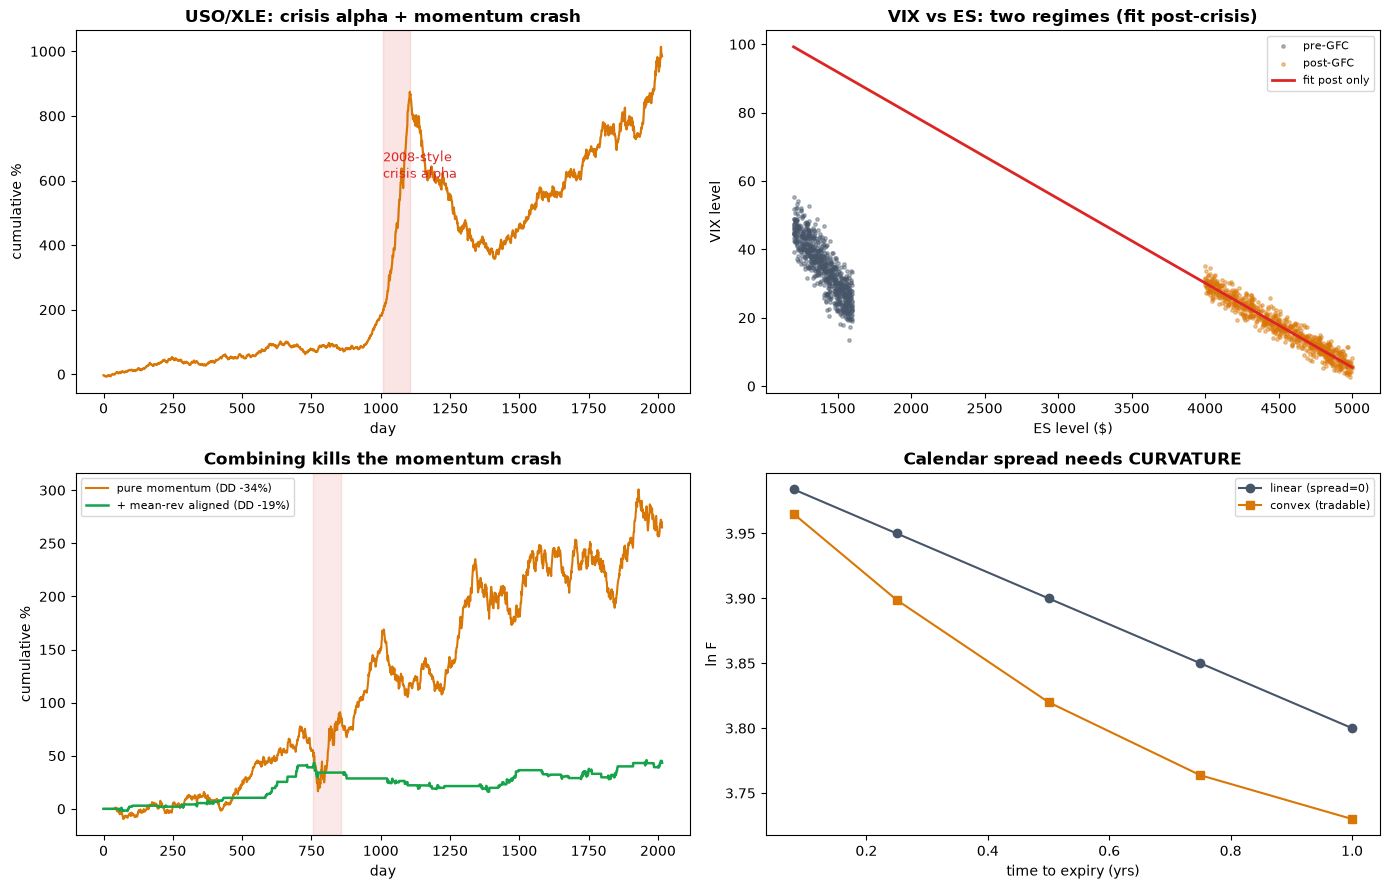

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
AM="#d97706"; AM2="#f59e0b"; SL="#475569"; RED="#dc2626"; GR="#16a34a"

# (1) USO/XLE: crisis alpha then momentum crash
ax[0,0].plot((eq_oil-1)*100, color=AM, lw=1.6)
ci = np.where(crisis)[0]
ax[0,0].axvspan(ci[0], ci[-1], color=RED, alpha=0.12)
ax[0,0].text(ci[0], (eq_oil.max()-1)*100*0.6, "2008-style\ncrisis alpha", color=RED, fontsize=9)
ax[0,0].set_title("USO/XLE: crisis alpha + momentum crash", fontweight="bold")
ax[0,0].set_xlabel("day"); ax[0,0].set_ylabel("cumulative %")

# (2) VIX-ES regime scatter
ax[0,1].scatter(es_lvl[pre], vix_lvl[pre], s=6, color=SL, alpha=0.4, label="pre-GFC")
ax[0,1].scatter(es_lvl[post], vix_lvl[post], s=6, color=AM, alpha=0.4, label="post-GFC")
xx = np.linspace(es_lvl.min(), es_lvl.max(), 50)
ax[0,1].plot(xx, np.polyval(np.polyfit(es_lvl[post], vix_lvl[post],1), xx), color=RED, lw=2, label="fit post only")
ax[0,1].set_title("VIX vs ES: two regimes (fit post-crisis)", fontweight="bold")
ax[0,1].set_xlabel("ES level ($)"); ax[0,1].set_ylabel("VIX level"); ax[0,1].legend(fontsize=8)

# (3) momentum crash vs combined
ax[1,0].plot((eq_m-1)*100, color=AM, lw=1.5, label=f"pure momentum (DD {ddm*100:.0f}%)")
ax[1,0].plot((eq_c-1)*100, color=GR, lw=1.8, label=f"+ mean-rev aligned (DD {ddc*100:.0f}%)")
mc = np.where(cri)[0]
ax[1,0].axvspan(mc[0], mc[-1], color=RED, alpha=0.10)
ax[1,0].set_title("Combining kills the momentum crash", fontweight="bold")
ax[1,0].set_xlabel("day"); ax[1,0].set_ylabel("cumulative %"); ax[1,0].legend(fontsize=8)

# (4) term structure curvature -> roll
ax[1,1].plot(T, logF_linear, "o-", color=SL, label="linear (spread=0)")
ax[1,1].plot(T, logF_convex, "s-", color=AM, label="convex (tradable)")
ax[1,1].set_title("Calendar spread needs CURVATURE", fontweight="bold")
ax[1,1].set_xlabel("time to expiry (yrs)"); ax[1,1].set_ylabel("ln F"); ax[1,1].legend(fontsize=8)

plt.tight_layout(); plt.savefig("chart_1_momentum2.png", dpi=115, bbox_inches="tight")
print("saved chart_1_momentum2.png")

## 10. The one-paragraph version

Part II turns the roll return into trades. A **perfect** hedge (short GC, long GLD) has a Sharpe of
**zero** — no risk means you only earn the risk-free rate, so excess return vanishes. The fix is an
**imperfect** hedge: **short USO / long XLE** harvests the oil roll, prints **+120% in the 2008
crisis** (momentum is *crisis alpha*), then suffers the inevitable **momentum crash** afterward. The
**VIX future** carries a brutal **−50% roll** that is really option **theta** in disguise; you short it
and hedge the spot with the **anti-correlated E-mini** (sell *both*, because they're anti-correlated),
sizing the hedge by regressing in **dollar** units (ES tick \$50, VX tick \$1000) on the
**post-crisis regime only** — and never regress without the **scatter plot** first. To *find* momentum
without a causal story, scan **serial autocorrelation** over a look-back/hold pair (≈250/25), but
remember overlapping windows **violate IID** and fake your p-value — sample every `min(L,H)` days; the
simplest rule (buy if the look-back return is positive, hold H days) already gives Sharpe ~1, and
**combining** it with a faster mean-reversion signal (trade only when aligned) **removes the crash**.
Finally, **calendar spreads** need **curvature** (roll = −slope, so on a convex curve you short the
*front*), and **3× ETFs** both suffer **volatility drag** ($g=\mu-\tfrac12\sigma^2$) and create
tradable **end-of-day momentum** through forced rebalancing. Every one of these is a *starting point* —
profit comes from the bells and whistles you add.